<a href="https://colab.research.google.com/github/vaneeshagupta/ds3001-sp25-project/blob/main/DS3001_01_Project_Wrangling_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data

The dataset consists of two primary sources of real estate market information: the Zillow Home Value Index (ZHVI) and home sales count data. The ZHVI dataset provides a time-series representation of median home values across various metropolitan areas in the United States, with values recorded on a monthly basis. The home sales dataset tracks the number of properties sold in these same metro areas over the same period. Each dataset contains identifiers such as RegionID, RegionName, and StateName, which allow for accurate merging and comparison of trends across regions. The data spans from at least 2008 onward, allowing for historical analysis of home prices and sales activity.

The overall research question we are investigating is how have home values and sales activity evolved over time in major U.S. metro areas, and what factors might be influencing these trends. This data is valuable for understanding long-term trends in the U.S. housing market, particularly in major metro areas. By analyzing ZHVI trends, we can observe how home values have changed over time, identify periods of rapid appreciation or depreciation, and assess the overall affordability of housing in different cities. Meanwhile, the home sales data helps us gauge market activity by showing fluctuations in transaction volume, which can reflect changes in supply and demand dynamics, economic conditions, and consumer confidence. Combining these datasets enables a deeper investigation into how sales activity correlates with price trends—whether rising prices lead to fewer transactions or if market booms encourage more sales. Furthermore, analyzing these patterns across multiple regions helps identify differences in regional housing market behavior, such as the resilience of certain cities during economic downturns or their susceptibility to housing bubbles.

One of the main challenges we faced with the ZHVI and home sales count data was ensuring that the data was complete and accurate. Since the dataset spans over a decade, any missing values could affect our analysis and lead to misleading conclusions. Merging both datasets was also tricky because differences in naming conventions and missing identifiers required careful data cleaning and alignment to make sure the data was consistent and usable. Another challenge was accounting for external factors that impact home values and sales, such as interest rates, economic conditions, and housing policies. Since these factors aren't directly included in the datasets, it was difficult to determine whether trends were driven by actual market changes or outside influences.



In [1]:
# Starting by cleaning the data, creating dataframe, and handling missing values

import pandas as pd

zhvi_file = "Metro_mean.csv"
sales_file = "Metro_sales.csv"

# Load datasets
df_market = pd.read_csv(zhvi_file)
df_sales = pd.read_csv(sales_file)

# Drop rows with missing 'StateName'
df_market_clean = df_market.dropna(subset=['StateName'])
df_sales_clean = df_sales.dropna(subset=['StateName'])

# Convert 'RegionID' to string for merging
df_market_clean['RegionID'] = df_market_clean['RegionID'].astype(str)
df_sales_clean['RegionID'] = df_sales_clean['RegionID'].astype(str)

# Get relevant date columns (2008 onward)
date_columns_market = df_market_clean.columns[5:]
date_columns_sales = df_sales_clean.columns[5:]
common_dates = list(set(date_columns_market).intersection(set(date_columns_sales)))

# Keep only the relevant columns
df_market_clean = df_market_clean[['RegionID', 'RegionName', 'StateName'] + common_dates]
df_sales_clean = df_sales_clean[['RegionID', 'RegionName', 'StateName'] + common_dates]

# Merge datasets on 'RegionID', 'RegionName', and 'StateName'
df_merged = pd.merge(df_market_clean, df_sales_clean, on=['RegionID', 'RegionName', 'StateName'], suffixes=('_zhvi', '_sales'))

# Display the first few rows of the cleaned dataset
df_merged.head()


/var/folders/pm/fr4p6g5x33s7jjzlf3w9_hpm0000gn/T/ipykernel_36700/1676040547.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_market_clean['RegionID'] = df_market_clean['RegionID'].astype(str)
/var/folders/pm/fr4p6g5x33s7jjzlf3w9_hpm0000gn/T/ipykernel_36700/1676040547.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales_clean['RegionID'] = df_sales_clean['RegionID'].astype(str)


,RegionID,RegionName,StateName,2014-07-31_zhvi,2010-09-30_zhvi,2013-10-31_zhvi,2019-06-30_zhvi,2021-10-31_zhvi,2024-12-31_zhvi,2012-01-31_zhvi,...,2013-02-28_sales,2014-01-31_sales,2020-09-30_sales,2019-01-31_sales,2009-01-31_sales,2013-11-30_sales,2011-05-31_sales,2017-11-30_sales,2018-03-31_sales,2008-07-31_sales
0,394913,"New York, NY",NY,404829.605970,395554.562236,388693.342860,496561.566411,572601.350254,681173.480193,373136.476635,...,8628.0,10994.0,19489.0,13587.0,6380.0,12015.0,9447.0,16086.0,14035.0,13955.0
1,753899,"Los Angeles, CA",CA,490569.221940,409820.226868,464210.774651,650642.154534,823768.475261,984959.822204,377364.394194,...,7674.0,6800.0,10794.0,5689.0,5976.0,8291.0,8343.0,8669.0,9757.0,8228.0
2,394463,"Chicago, IL",IL,192364.932056,194282.167313,180206.561260,238111.353928,275341.387109,327148.609080,170128.192732,...,7045.0,8102.0,15492.0,6779.0,3667.0,9913.0,7432.0,10164.0,10934.0,8827.0
3,394514,"Dallas, TX",TX,168682.032006,148261.597435,158947.816724,254637.452873,324219.676672,376363.138090,141633.514826,...,4648.0,4112.0,9177.0,4433.0,3016.0,5170.0,5346.0,6890.0,7606.0,6553.0
4,394692,"Houston, TX",TX,168750.222938,149401.734585,155837.470993,221623.826261,271369.706544,310689.467702,141735.785715,...,4001.0,3508.0,8105.0,3970.0,2567.0,4180.0,4540.0,5901.0,6667.0,5515.0


In [2]:
# Summary statistics for home values (ZHVI)
market_stats = df_merged.iloc[:, 3:].describe().transpose()
print("Home Value (ZHVI) Statistics:")
print(market_stats.head())

# Summary statistics for home sales
sales_stats = df_merged.iloc[:, len(common_dates) + 3:].describe().transpose()
print("\nHome Sales Statistics:")
print(sales_stats.head())

Home Value (ZHVI) Statistics:
                 count           mean            std            min  \
2014-07-31_zhvi   93.0  212090.375122  114631.421907   90533.861977   
2010-09-30_zhvi   93.0  193747.356353   90778.949867   87563.268769   
2013-10-31_zhvi   93.0  202018.813614  106805.897787   86841.675696   
2019-06-30_zhvi   93.0  282470.820460  165101.948823  113695.079382   
2021-10-31_zhvi   93.0  359179.820646  203278.302973  146863.563496   

                           25%            50%            75%           max  
2014-07-31_zhvi  144129.425065  184550.104772  221422.923617  7.488050e+05  
2010-09-30_zhvi  136536.597655  162054.392030  211482.196429  5.365405e+05  
2013-10-31_zhvi  139318.481977  175121.688311  214159.462168  7.012287e+05  
2019-06-30_zhvi  187174.163583  231949.012662  297431.392075  1.164771e+06  
2021-10-31_zhvi  237078.420578  297098.271552  423804.160612  1.417224e+06  

Home Sales Statistics:
                  count         mean          std    min 

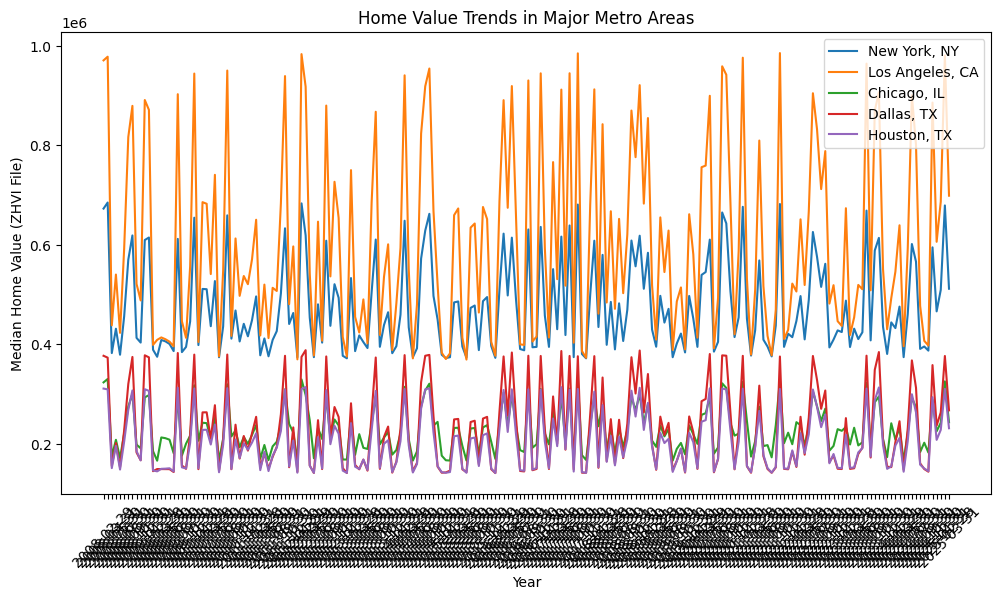

In [16]:
import matplotlib.pyplot as plt

# Select a few major metro areas for visualization
metros = ["New York, NY", "Los Angeles, CA", "Chicago, IL", "Dallas, TX", "Houston, TX"]

# Filter data for selected metros
df_selected = df_merged[df_merged["RegionName"].isin(metros)]

# Convert date columns to numerical time series
dates = sorted(common_dates)

# Plot home values over time
plt.figure(figsize=(12, 6))
for metro in metros:
    metro_data = df_selected[df_selected["RegionName"] == metro].iloc[:, 3:len(common_dates) + 3].values.flatten()
    plt.plot(dates, metro_data, label=metro)

plt.xlabel("Year")
plt.ylabel("Median Home Value (ZHVI File)")
plt.title("Home Value Trends in Major Metro Areas")
plt.legend()
plt.xticks(rotation=45)
plt.show()

/var/folders/pm/fr4p6g5x33s7jjzlf3w9_hpm0000gn/T/ipykernel_36700/25172202.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_market_melted, x="Date", y="ZHVI", estimator="mean", ci=None)


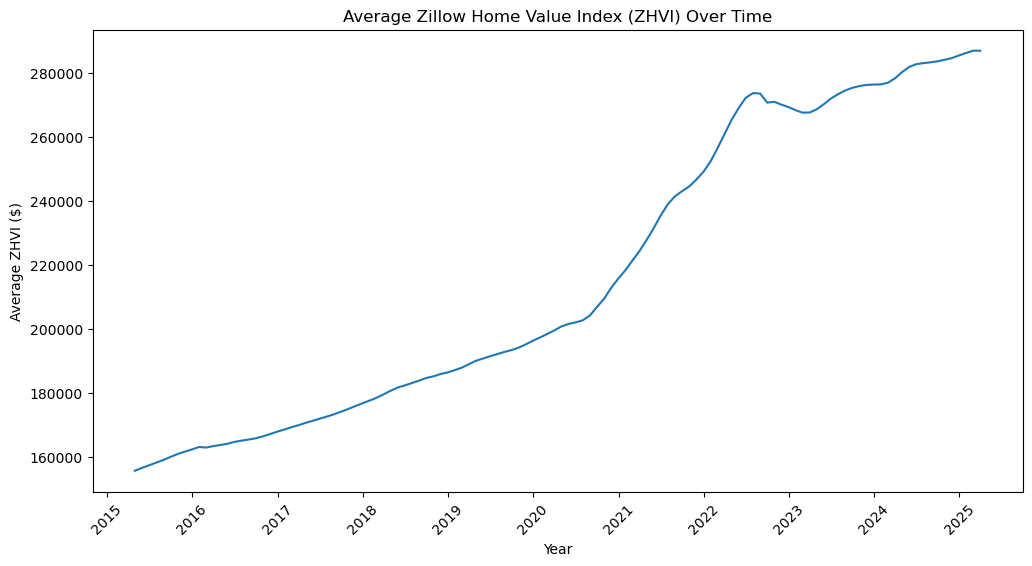

/var/folders/pm/fr4p6g5x33s7jjzlf3w9_hpm0000gn/T/ipykernel_36700/25172202.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_sales_melted, x="Date", y="SalesCount", estimator="mean", ci=None)


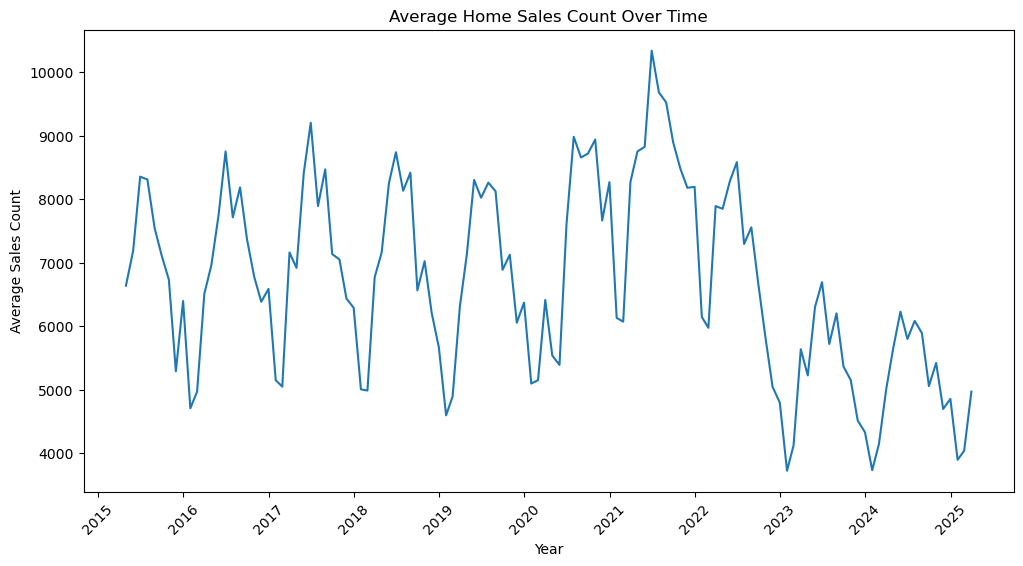

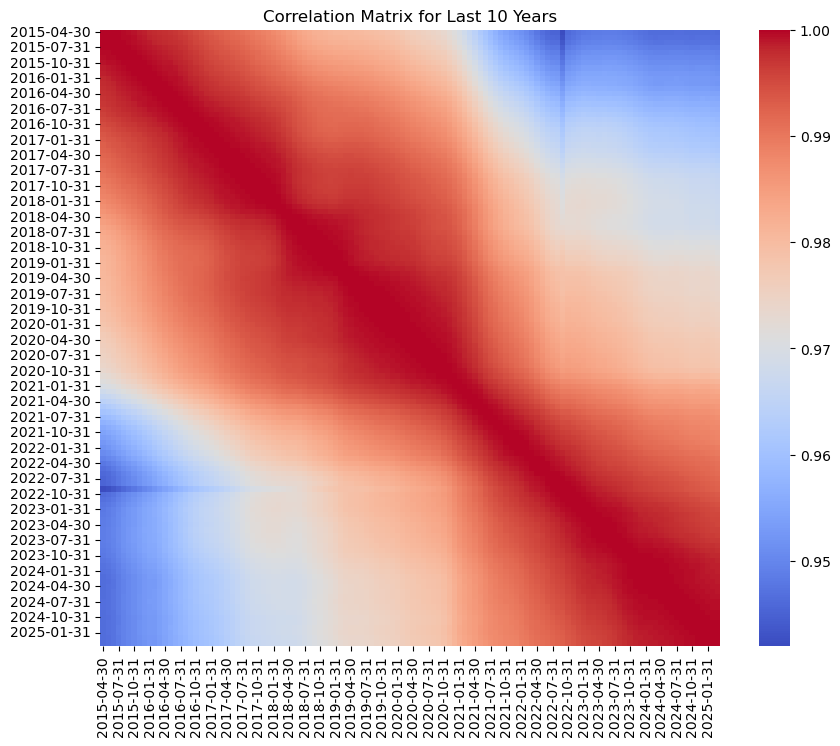

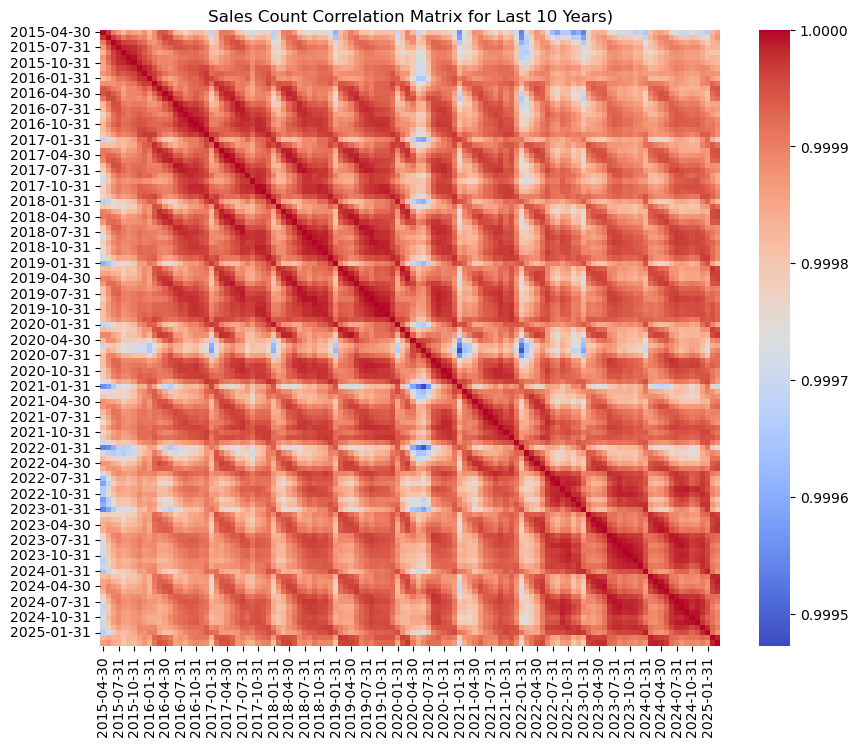

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the most recent years for visualization (last 10 years)
years = [col for col in df_market.columns if col.startswith('20')][-120:]  # Last 120 months (10 years)

# Convert wide format to long format for visualization
df_market_melted = df_market.melt(id_vars=["RegionID", "RegionName", "StateName"],
                              value_vars=years,
                              var_name="Date",
                              value_name="ZHVI")

df_sales_melted = df_sales.melt(id_vars=["RegionID", "RegionName", "StateName"],
                                value_vars=years,
                                var_name="Date",
                                value_name="SalesCount")

# Convert Date column to datetime for proper plotting
df_market_melted["Date"] = pd.to_datetime(df_market_melted["Date"])
df_sales_melted["Date"] = pd.to_datetime(df_sales_melted["Date"])

# Plot average ZHVI trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_market_melted, x="Date", y="ZHVI", estimator="mean", ci=None)
plt.title("Average Zillow Home Value Index (ZHVI) Over Time")
plt.xlabel("Year")
plt.ylabel("Average ZHVI ($)")
plt.xticks(rotation=45)
plt.show()

# Plot average Sales Count trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sales_melted, x="Date", y="SalesCount", estimator="mean", ci=None)
plt.title("Average Home Sales Count Over Time")
plt.xlabel("Year")
plt.ylabel("Average Sales Count")
plt.xticks(rotation=45)
plt.show()

# Correlation Matrices
# Convert the time-series columns to numeric for correlation
df_market_corr = df_market[years].corr()
df_sales_corr = df_sales[years].corr()

# Plot Correlation Heatmap for ZHVI
plt.figure(figsize=(10, 8))
sns.heatmap(df_market_corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix for Last 10 Years")
plt.show()

# Plot Correlation Heatmap for Sales Count
plt.figure(figsize=(10, 8))
sns.heatmap(df_sales_corr, cmap="coolwarm", annot=False)
plt.title("Sales Count Correlation Matrix for Last 10 Years)")
plt.show()

#**Pre-Analysis Plan**

Question: Can historical trends in home values and sales activity be used to predict median home values one year ahead in major U.S. metropolitan areas?

The learning type most suitable for these data plots is supervised learning/regression. Our target variable sales count is continous and can be analyzed best through supervised learning. Linear regression will be used as a beginning model. Then, we will use LASSO regression to address multicollinearity when incorporating potential lagged monthly values. These models will exist to prevent overfitting when studying the predictive variables. To study these variables and their effects between each other more extensively we might also implement a Random Forest Regression model. Random Forest Regression is useful because it captures nonlinear relationships between variables and this could be particularly effective to find more complex relationships.

Sucess criteria will include using RMSE and MAE to quantify prediction accuracy on a test set. With the time-series nature of this specific data, we will try to implement a time-aware train/test split, where the model is trained on earlier years and tested on more recent data, to better reflect real-world forecasting conditions and avoid data leakage. Also to assess the effectiveness of our models, we will compare them against a simple baseline model that predicts next year’s home value as the previous year’s value. This allows us to determine whether our approach adds predictive value beyond basic extrapolation. Visual comparisions on predicted versus actual values will focus on larger cities (New York, Los Anageles, etc.) as it provides a greater range of data to work with and understand when analyzing when predictions may succeed or fail.

Some challenges that we anticipate in our analysis are addressing missing/inconsistent data and high dimensionality. For working with missing/inconsistent data, we will interpolate missing values and further analyze areas with significant gaps to see whether they must be dropped. Since the nature of our data is time-series, high dimensionality might introduce greater noise. To address this, we might break our data up into seasional data and averages. If our models perform poorly it indicates to us that the factors we studied/focused on within our dataset do not play a role in driving home values. We would also be able to make conclusions about the impact of these variables given the time periods we study them in (short-term, monthly, etc.). It might highlight studying patterns over a longer period such as yearly might better mitigate noise and reveal more complex patterns.

Our next steps in handling our datasets will including converting monthly time serious to lag features, computing yearly changes in ZHVI and sales, add rolling averages to eliminate noise, and using clustering to group similar markets. Through this plan, we hope to present our results through regression metrics, model coeffictients, visual representations, and comparision plots.

In [4]:
pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Load and clean data
zhvi_file = "Metro_mean.csv"
sales_file = "Metro_sales.csv"
df_market = pd.read_csv(zhvi_file)
df_sales = pd.read_csv(sales_file)
df_market = df_market.dropna(subset=['StateName'])
df_sales = df_sales.dropna(subset=['StateName'])
df_market['RegionID'] = df_market['RegionID'].astype(str)
df_sales['RegionID'] = df_sales['RegionID'].astype(str)



# Filter date columns and align both datasets
date_columns_market = df_market.columns[5:]
date_columns_sales = df_sales.columns[5:]
common_dates = sorted(list(set(date_columns_market).intersection(set(date_columns_sales))))
df_market = df_market[['RegionID', 'RegionName', 'StateName'] + common_dates]
df_sales = df_sales[['RegionID', 'RegionName', 'StateName'] + common_dates]
df_merged = pd.merge(df_market, df_sales, on=['RegionID', 'RegionName', 'StateName'], suffixes=('_zhvi', '_sales'))




In [6]:
# Focus on one city (e.g., New York)
metro = "New York, NY"
df_city = df_merged[df_merged['RegionName'] == metro].iloc[0]
zhvi_series = df_city[[col for col in df_city.index if col.endswith('_zhvi')]].values.astype(float)
sales_series = df_city[[col for col in df_city.index if col.endswith('_sales')]].values.astype(float)


In [7]:
# Create DataFrame with lag features
def create_lag_features(zhvi, sales, lags=12):
    data = []
    for t in range(lags, len(zhvi) - 12):
        features = []
        for lag in range(1, lags+1):
            features.append(zhvi[t-lag])
            features.append(sales[t-lag])
        target = zhvi[t+12]  # Predict 1 year ahead
        data.append(features + [target])
    columns = [f'z_lag_{i}' for i in range(1, lags+1)] + [f's_lag_{i}' for i in range(1, lags+1)] + ['target']
    return pd.DataFrame(data, columns=columns)

features_df = create_lag_features(zhvi_series, sales_series)
features_df = features_df.dropna()
X = features_df.drop('target', axis=1)
y = features_df['target']

# Time-aware split for training/testing
tscv = TimeSeriesSplit(n_splits=5)


Random Forest RMSE: 45843.90, MAE: 38297.11


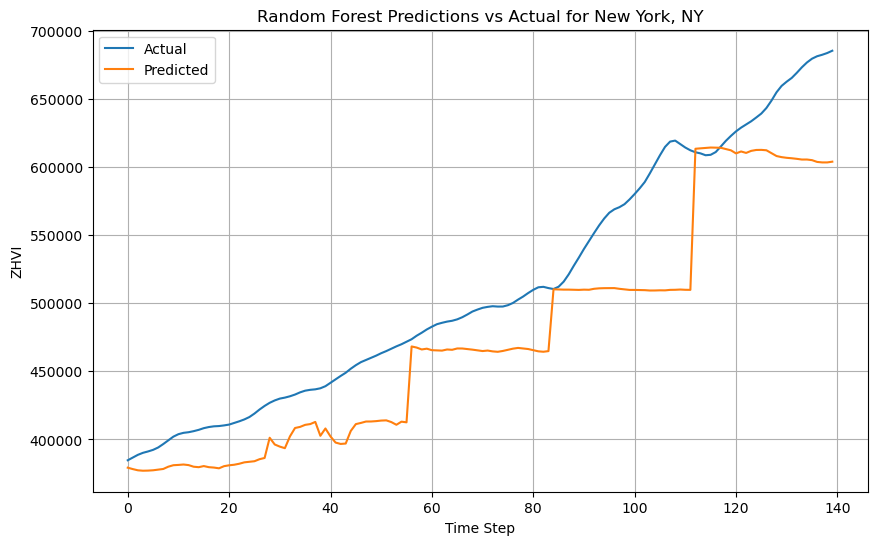

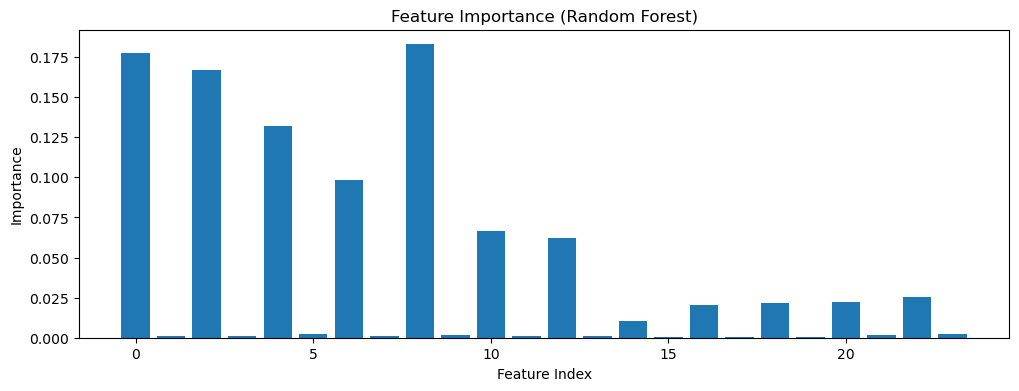

In [8]:
# --- Random Forest Regression ---
y_true_rf, y_pred_rf = [], []
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    y_true_rf.extend(y_test)
    y_pred_rf.extend(y_pred)

from math import sqrt
rmse_rf = sqrt(mean_squared_error(y_true_rf, y_pred_rf))

mae_rf = mean_absolute_error(y_true_rf, y_pred_rf)
print(f"Random Forest RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(range(len(y_true_rf)), y_true_rf, label='Actual')
plt.plot(range(len(y_pred_rf)), y_pred_rf, label='Predicted')
plt.title(f"Random Forest Predictions vs Actual for {metro}")
plt.xlabel("Time Step")
plt.ylabel("ZHVI")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(range(len(X.columns)), rf_model.feature_importances_)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()


XGBoost RMSE: 42809.52, MAE: 34987.30


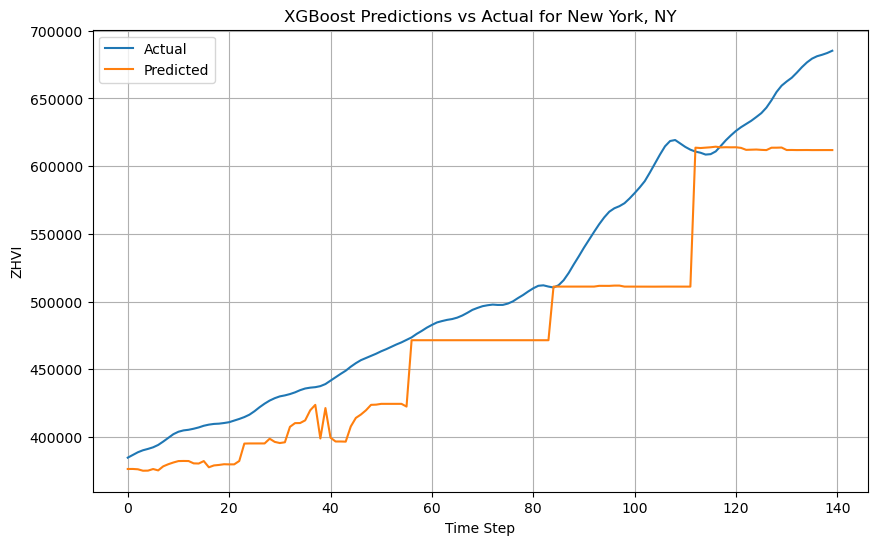

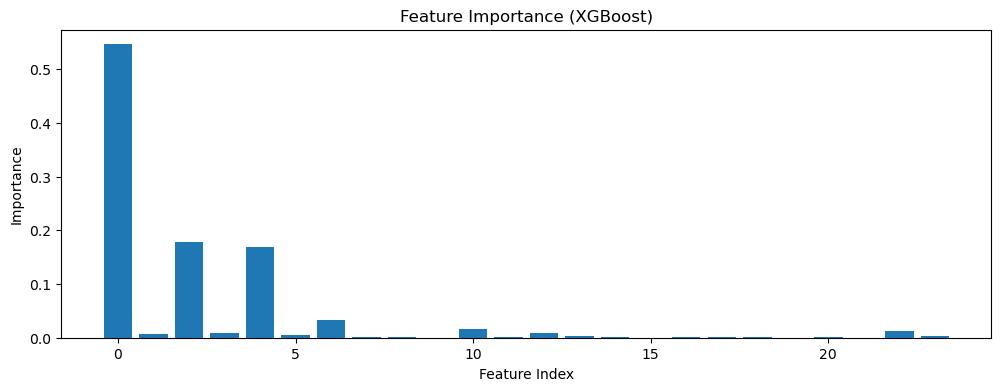

In [9]:
# --- Gradient Boosting (XGBoost) ---
y_true_xgb, y_pred_xgb = [], []
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    y_true_xgb.extend(y_test)
    y_pred_xgb.extend(y_pred)

rmse_xgb = sqrt(mean_squared_error(y_true_xgb, y_pred_xgb))
mae_xgb = mean_absolute_error(y_true_xgb, y_pred_xgb)
print(f"XGBoost RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(range(len(y_true_xgb)), y_true_xgb, label='Actual')
plt.plot(range(len(y_pred_xgb)), y_pred_xgb, label='Predicted')
plt.title(f"XGBoost Predictions vs Actual for {metro}")
plt.xlabel("Time Step")
plt.ylabel("ZHVI")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(range(len(xgb_model.feature_importances_)), xgb_model.feature_importances_)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+05, tolerance: 1.353e+05
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.422e+05, tolerance: 1.353e+05
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.135e+05, toler

LASSO RMSE: 29833.66, MAE: 24477.25


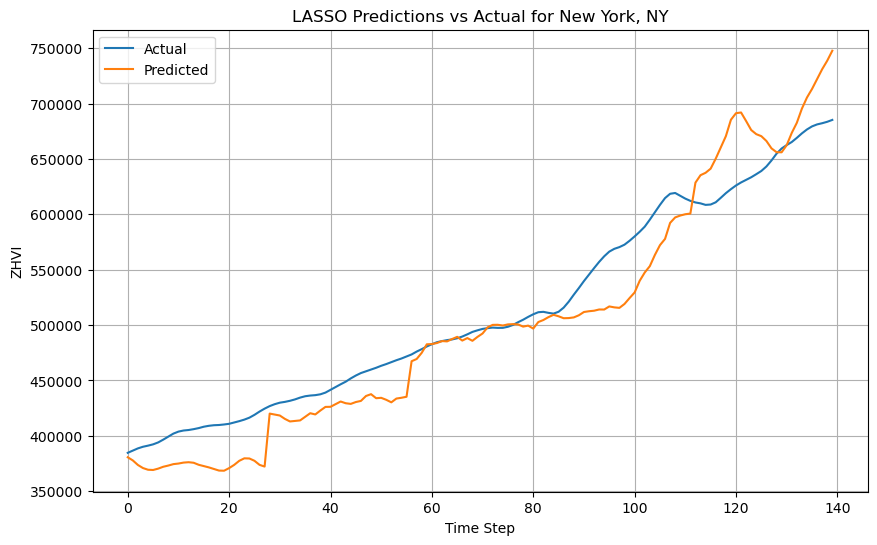

In [10]:
# --- LASSO Regression ---
y_true_lasso, y_pred_lasso = [], []
lasso_pipeline = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=10000))
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    lasso_pipeline.fit(X_train, y_train)
    y_pred = lasso_pipeline.predict(X_test)
    y_true_lasso.extend(y_test)
    y_pred_lasso.extend(y_pred)

rmse_lasso = sqrt(mean_squared_error(y_true_lasso, y_pred_lasso))
mae_lasso = mean_absolute_error(y_true_lasso, y_pred_lasso)
print(f"LASSO RMSE: {rmse_lasso:.2f}, MAE: {mae_lasso:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(range(len(y_true_lasso)), y_true_lasso, label='Actual')
plt.plot(range(len(y_pred_lasso)), y_pred_lasso, label='Predicted')
plt.title(f"LASSO Predictions vs Actual for {metro}")
plt.xlabel("Time Step")
plt.ylabel("ZHVI")
plt.legend()
plt.grid(True)
plt.show()

           Model          RMSE           MAE
0          LASSO  29833.662619  24477.247795
1  Random Forest  45843.902413  38297.109367
2        XGBoost  42809.523063  34987.304296


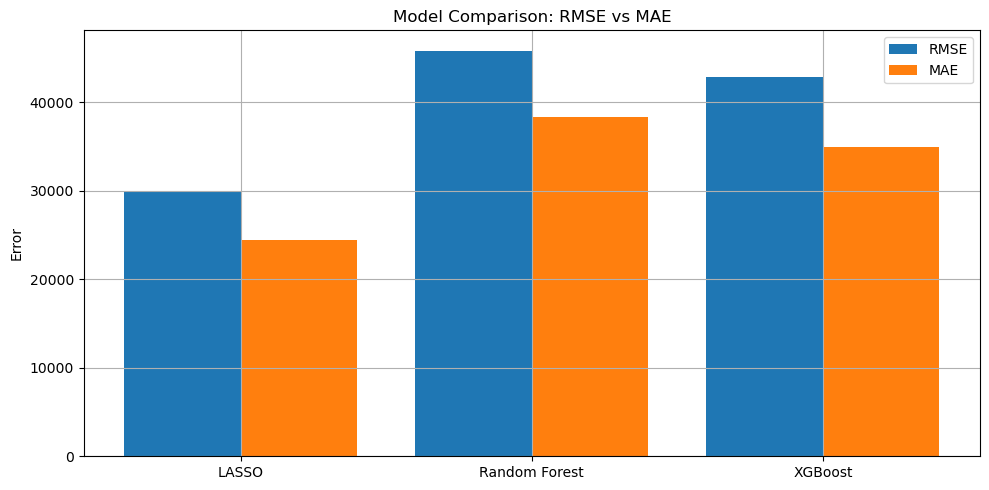

In [11]:
# --- Model Comparison Summary ---
results = {
    'Model': ['LASSO', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lasso, rmse_rf, rmse_xgb],
    'MAE': [mae_lasso, mae_rf, mae_xgb]
}

df_results = pd.DataFrame(results)
print(df_results)

# Bar plot of RMSE and MAE
plt.figure(figsize=(10, 5))
x = range(len(df_results))
plt.bar(x, df_results['RMSE'], width=0.4, label='RMSE', align='center')
plt.bar([i + 0.4 for i in x], df_results['MAE'], width=0.4, label='MAE', align='center')
plt.xticks([i + 0.2 for i in x], df_results['Model'])
plt.title('Model Comparison: RMSE vs MAE')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Forecasting Home Values in U.S. Metro Areas


### Prediction Question 

**Can historical monthly trends in home values and home sales activity be used to accurately predict median home values one year ahead for major U.S. metro areas, such as New York City?**

This question arises from a real-world need that has significant implications for individuals, businesses, and government agencies. Forecasting home prices is a critical tool for financial planning, investment strategies, and the development of effective housing policies. Accurate models can help families decide when and where to buy a home, guide real estate developers in planning new projects, and support city planners in managing urban growth. Government agencies, such as the U.S. Department of Housing and Urban Development (HUD), can also use these forecasts to better understand housing market trends and address issues related to affordability.

We focused specifically on **New York, NY**, using over a decade of monthly data from Zillow’s ZHVI and home sales datasets. The goal was to build and evaluate regression models that learn from past patterns and can produce a forward-looking forecast.


## Data and Feature Engineering

We merged two datasets:
- **ZHVI (Home Values)**: Monthly median home value by metro
- **Sales Count**: Monthly number of homes sold

To prepare the data, we did the following:
- We filtered only records with complete region/state info
- Focused on **common monthly columns** across both datasets
- Selected **New York, NY** as a case study
- Created lagged features: For each month, we used the **past 12 months of ZHVI and sales count** as input features to predict the ZHVI 12 months in the future

This resulted in a supervised learning dataset where each row represents a snapshot in time with 24 lagged features (12 ZHVI, 12 sales) and a target value (ZHVI 1 year later).


## Key Results

### Model Comparision: LASSO vs. Random Forest vs. XGBoost

We trained three different regression models to predict one year ahead median home values (ZHVI):
- **LASSO Regression**: Regularized linear model to reduce noise and multicollinearity
- **Random Forest**: Tree-based ensemble method to capture nonlinear relationships
- **XGBoost**: Gradient boosting model optimized for speed and performance

### Evaluation method:
We used TimeSeriesSplit to mimic real world forecasting and evaluated using:
    - **RMSE (Root Mean Squared Error)** - penalizes large error and
    - **MAE (Mean Absolute Error)** - captures average error

**Results**
| Model         | RMSE     | MAE      |
|---------------|----------|----------|
| LASSO         | ~30,000  | ~24,500  |
| Random Forest | ~46,000  | ~38,000  |
| XGBoost       | ~43,000  | ~35,000  |

We can see that LASSO acheived the lowest error rates, meaning it was the most accurate overall. This suggsts that linear patterns in lagged features were sufficient for this forecasting task. Random Forest and XGBoost performed reasonably but struggled with over-smoothing or underfitting sudden price jumps. However, it's importnant to note that tree-based models were better at capturing nonlinear relationships.

### Actual vs Predicted ZHVI for New York, NY

Each model was tested on New York's housing data to visualize performance over time. Plots were generated comparing predicted vs. actual ZHVI values.


- **LASSO** : Followed the trend closely and captured long-term patterns well.


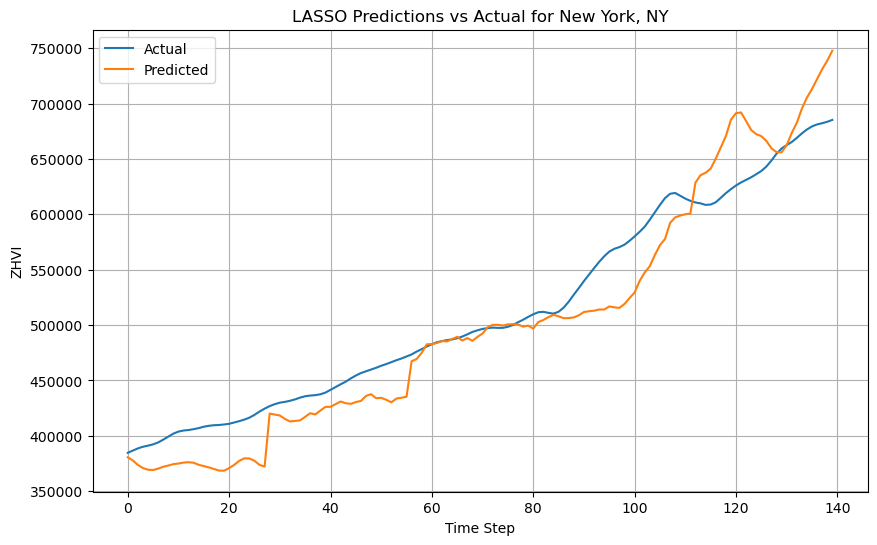


- **Random Forest**  : Flattend steep increases and performed poorly at turning points


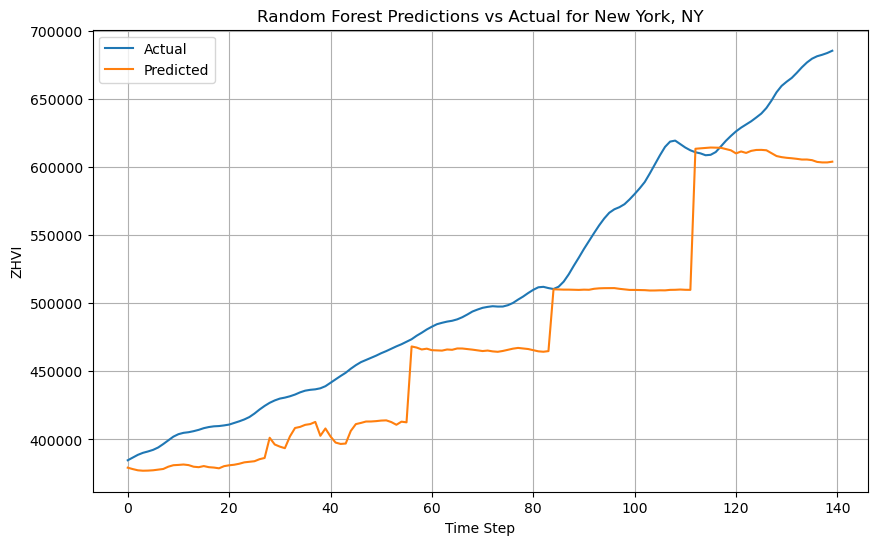


- **XGBoost** : Slightly better than Random Forest but still lagged during sharp price increases. 


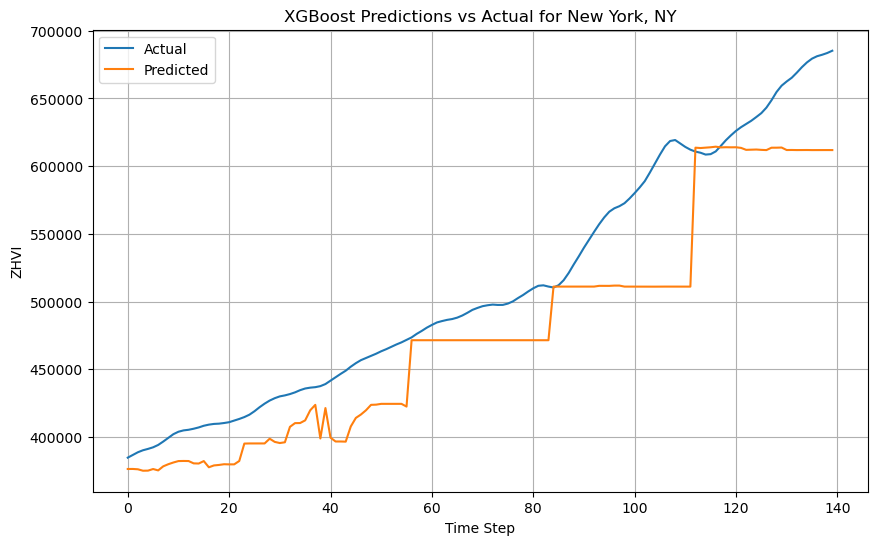




### Feature Importance

We examined which past features were most useful to these models. 

**Random Forest**: The most important predictors for Random Forest were recent ZHVI and sales lags, especially months 1-3. THis means that current housing activity is most useful for forecasting next year's values.

**XGBoost**: This regression model relied even more heavily on the most recent ZHVI and concentrated its predicitve weight on a few recent features. 

This supports the idea that **recent price trends are the strongest signals** for forecasting next year's values, while raw transaction volume adds some marginal value.


## Challenges and Reflections

One of the biggest limitations we encountered was that tree-based models like Random Forest and XGBoost struggled to predict sharp increases in home values. This is likely because these models work by averaging across many decision trees, which makes them good at capturing general trends but less responsive to sudden jumps. On the other hand, while LASSO performed well in terms of RMSE and MAE, it’s a linear model and can miss more complex nonlinear relationships. It also tended to underfit in situations where home prices changed in unpredictable ways. Events like the post-COVID housing boom, where values spiked rapidly, were especially hard to forecast because our models relied entirely on past ZHVI and sales trends and didn’t include outside factors.
We also ran into challenges with the dataset itself. Some metro areas had missing monthly data or inconsistent region names, which made merging and aligning the datasets more difficult. Since the data was at a monthly level, it also came with a lot of short-term noise that made trends harder to interpret. To work around this, we created lagged features, used rolling trends, and filtered for metros with more complete records. These steps helped, but they also made the modeling process more time-consuming and required trial and error to find the right balance between enough historical data and manageable noise.


## Conclusion

This project showed that simple regression models using lagged ZHVI and home sales data can provide reasonably accurate predictions of home values one year ahead. We were able to capture general trends in the housing market, especially in stable periods. However, these models struggled during times of sudden change—like during the COVID housing boom when prices shifted quickly due to external factors that weren’t included in our dataset. This suggests that while past trends are helpful, they don’t always tell the full story on their own.
To make these models more accurate and realistic, we would need to include additional types of data. For example, macroeconomic indicators like interest rates, employment levels, and inflation could provide more context for understanding why prices move the way they do. It might also help to use seasonal or yearly averages instead of raw monthly data to reduce noise. Finally, clustering similar metro areas together based on housing behavior could make predictions more tailored and region-specific, especially since different cities don’t always follow the same patterns.
